$$ ITI \space AI-Pro: \space Intake \space 45 $$
$$ Machine \space Learning \space 1 $$
$$ Lab \space no. \space 5 $$

# `01` Import Necessary Libraries

## `i` Default Libraries

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

## `ii` Additional Libraries
Add imports for additional libraries you used throughout the notebook

In [ ]:
import warnings
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler,StandardScaler,QuantileTransformer
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree, export_text
from sklearn.metrics import accuracy_score,precision_score,f1_score,confusion_matrix,classification_report
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
warnings.filterwarnings("ignore")


----------------------------

# `02` Load Data

Note: Make sure the `Data` folder attached with the notebook is in the same path for this cell to work properly.

[Dataset Link](https://www.kaggle.com/datasets/parisrohan/credit-score-classification)

In [ ]:
# prompt: connect with drive

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
train = pd.read_csv("/content/drive/MyDrive/credit_data/train.csv")
test = pd.read_csv("/content/drive/MyDrive/credit_data/test.csv")

In [ ]:
train.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [ ]:
train.shape

(100000, 28)

In [ ]:
test.shape

(50000, 27)

----------------

# `03` Exploratory Data Analysis (EDA)

## `i` Simple Analysis

Preview data, perform statistical data analysis and explore as much as needed to better understand the data set we're dealing with.

`Notes:`
- Feel free to look up EDA approaches online for inspiration (however you **must understand** everything and not copy paste).
- Make sure to add notes and insights extracted from your analysis.


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [ ]:
train.shape

(100000, 28)

In [ ]:
train.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,9985
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,15002
Num_Bank_Accounts,0


### there are missing value will prepare it in preparation stage

In [ ]:
train.duplicated().sum()

0

In [ ]:
train['Credit_Score'].value_counts()

,count
Credit_Score,
Standard,53174
Poor,28998
Good,17828


In [ ]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Inhand_Salary,84998.0,4194.170850,3183.686167,303.645417,1625.568229,3093.745000,5957.448333,15204.633333
Num_Bank_Accounts,100000.0,17.091280,117.404834,-1.000000,3.000000,6.000000,7.000000,1798.000000
Num_Credit_Card,100000.0,22.474430,129.057410,0.000000,4.000000,5.000000,7.000000,1499.000000
Interest_Rate,100000.0,72.466040,466.422621,1.000000,8.000000,13.000000,20.000000,5797.000000
Delay_from_due_date,100000.0,21.068780,14.860104,-5.000000,10.000000,18.000000,28.000000,67.000000
Num_Credit_Inquiries,98035.0,27.754251,193.177339,0.000000,3.000000,6.000000,9.000000,2597.000000
Credit_Utilization_Ratio,100000.0,32.285173,5.116875,20.000000,28.052567,32.305784,36.496663,50.000000
Total_EMI_per_month,100000.0,1403.118217,8306.041270,0.000000,30.306660,69.249473,161.224249,82331.000000


----------------

# `03` Data Preparation

Perform data cleaning, feature engineering, scaling, dropping unwanted columns (such as IDs), etc. as needed to make sure it's ready for the model.

`Q` Is this dataset *skewed*?

Hint: It could be helpful to check `sklearn.preprocessing` module.

In [ ]:
train.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [ ]:
train['Month'].value_counts()

,count
Month,
January,12500
February,12500
March,12500
April,12500
May,12500
June,12500
July,12500
August,12500


# Data Spliting

In [ ]:
fin_train,fin_val=train_test_split(train,test_size=0.2,random_state=1234)

# Occupation column

In [ ]:
fin_train['Occupation'].value_counts()

,count
Occupation,
_______,5663
Lawyer,5268
Architect,5124
Scientist,5047
Engineer,5027
Teacher,5021
Mechanic,5014
Accountant,4999
Developer,4981


In [ ]:
fin_train['Occupation'] = fin_train['Occupation'].replace("-------", np.nan)


In [ ]:
encoder = LabelEncoder()
fin_train['Occupation'] = encoder.fit_transform(fin_train['Occupation'].astype(str))

In [ ]:
Occup_impute=KNNImputer()
fin_train['Occupation']=Occup_impute.fit_transform(fin_train[['Occupation']])

In [ ]:
fin_train['Occupation'].value_counts()

,count
Occupation,
15.0,5663
7.0,5268
1.0,5124
12.0,5047
4.0,5027
13.0,5021
9.0,5014
0.0,4999
2.0,4981


In [ ]:
fin_val['Occupation'] = fin_val['Occupation'].replace("-------", np.nan)
fin_val['Occupation'] = encoder.transform(fin_val['Occupation'].astype(str))
fin_val['Occupation']=Occup_impute.transform(fin_val[['Occupation']])

# Age column

In [ ]:
fin_train['Age'] = fin_train['Age'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)
fin_train['Age']=fin_train['Age'].astype(int)

In [ ]:
fin_train['Age'].dtype

dtype('int64')

In [ ]:
fin_train['Age'] = fin_train['Age'].apply(lambda row: np.nan if (row <0) | (row >=65)  else row)

In [ ]:
Age_impute=KNNImputer()
fin_train['Age']=Age_impute.fit_transform(fin_train[['Age']])

In [ ]:
train['Age'].describe()

,Age
count,100000
unique,1788
top,38
freq,2833


In [ ]:
fin_val['Age'] = fin_val['Age'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)
fin_val['Age']=fin_val['Age'].astype(int)
fin_val['Age'] = fin_val['Age'].apply(lambda row: np.nan if (row <0) | (row >=65)  else row)
fin_val['Age']=Age_impute.transform(fin_val[['Age']])

# Annual_Income Column

In [ ]:
print(list(train['Annual_Income'].unique()))



['19114.12', '34847.84', '34847.84_', '143162.64', '30689.89', '30689.89_', '35547.71_', '35547.71', '73928.46', '131313.4', '10909427.0', '34081.38_', '34081.38', '114838.41', '114838.41_', '31370.8', '33751.27', '88640.24', '88640.24_', '54392.16', '54392.16_', '8701.545', '8701.545_', '25546.26', '25546.26_', '31993.78', '92047.08', '92047.08_', '32284.62', '97791.42', '97791.42_', '19300.34', '19514.88', '10183.015', '10183.015_', '106733.13', '106733.13_', '12600.445', '12600.445_', '57983.12', '57983.12_', '20787.69', '34290.12', '34290.12_', '43070.24', '43070.24_', '28572.39', '6515990.0_', '39641.54', '39641.54_', '20186.02', '586359.0', '18627.64', '12986.745', '58317.0', '42171.98', '71681.4', '29469.98', '29469.98_', '72559.36', '15566.02', '15566.02_', '66567.32', '12909.895', '30788.44', '20574.47', '20574.47_', '148699.32', '148699.32_', '85554.03', '55829.79', '18334118.0', '19717385.0', '14165.23', '14165.23_', '87215.68', '2709655.0', '81842.28', '81842.28_', '95956.5

In [ ]:
x='65000.73_'
x[-1]

'_'

In [ ]:
train['Annual_Income'].dtype

dtype('O')

In [ ]:

fin_train['Annual_Income'] = fin_train['Annual_Income'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)


In [ ]:
fin_train['Annual_Income']=fin_train['Annual_Income'].astype(float)

In [ ]:
fin_train['Annual_Income'].dtype

dtype('float64')

In [ ]:
fin_train['Annual_Income'].isna().sum()

0

In [ ]:
fin_val['Annual_Income'] = fin_val['Annual_Income'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)
fin_val['Annual_Income']=fin_val['Annual_Income'].astype(float)

# Monthly_Inhand_Salary column

In [ ]:
fin_train['Monthly_Inhand_Salary'].dtype

dtype('float64')

In [ ]:
fin_train['Monthly_Inhand_Salary'].fillna(fin_train['Monthly_Inhand_Salary'].mean(),inplace=True)

In [ ]:
fin_train['Monthly_Inhand_Salary'].isna().sum()

0

In [ ]:
fin_val['Monthly_Inhand_Salary'].fillna(fin_train['Monthly_Inhand_Salary'].mean(),inplace=True)

# Num_Bank_Accounts column

In [ ]:

fin_train['Num_Bank_Accounts'].dtype


dtype('int64')

In [ ]:
fin_train['Num_Bank_Accounts'].describe()

,Num_Bank_Accounts
count,80000.000000
mean,17.265037
std,118.894881
min,-1.000000
25%,3.000000
50%,6.000000
75%,7.000000
max,1798.000000


In [ ]:
fin_train['Num_Bank_Accounts'].isna().sum()

0

In [ ]:
fin_train['Num_Bank_Accounts'] = fin_train['Num_Bank_Accounts'].apply(lambda x: abs(x) if x<0 else x)

In [ ]:
fin_val['Num_Bank_Accounts'] = fin_val['Num_Bank_Accounts'].apply(lambda x: abs(x) if x<0 else x)

# Num_Credit_Card

In [ ]:
fin_train['Num_Credit_Card'].dtype

dtype('int64')

In [ ]:
fin_train['Num_Credit_Card'].describe()

,Num_Credit_Card
count,80000.000000
mean,22.548125
std,129.440226
min,0.000000
25%,4.000000
50%,5.000000
75%,7.000000
max,1499.000000


# Interest_Rate column

In [ ]:
print(fin_train['Interest_Rate'].describe())


count    80000.000000
mean        72.517900
std        468.031523
min          1.000000
25%          8.000000
50%         13.000000
75%         20.000000
max       5797.000000
Name: Interest_Rate, dtype: float64


In [ ]:
fin_train['Interest_Rate'].dtype

dtype('int64')

# Num_of_Loan column

In [ ]:

fin_train['Num_of_Loan'] = fin_train['Num_of_Loan'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)
fin_train['Num_of_Loan']=fin_train['Num_of_Loan'].astype(int)

In [ ]:
fin_train['Num_of_Loan'].describe()


,Num_of_Loan
count,80000.000000
mean,2.993888
std,63.053617
min,-100.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,1496.000000


In [ ]:
fin_train['Num_of_Loan']=fin_train['Num_of_Loan'].apply(lambda x: abs(x) if x<0 else x  )

In [ ]:
fin_val['Num_of_Loan'] = fin_val['Num_of_Loan'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)
fin_val['Num_of_Loan']=fin_val['Num_of_Loan'].astype(int)
fin_val['Num_of_Loan']=fin_val['Num_of_Loan'].apply(lambda x: abs(x) if x<0 else x  )

# Type_of_Loan column

In [ ]:
loans=train.groupby('Customer_ID')['Type_of_Loan'].value_counts().reset_index(name='Count')
loans

,Customer_ID,Type_of_Loan,Count
0,CUS_0x1000,"Credit-Builder Loan, and Home Equity Loan",8
1,CUS_0x1009,"Not Specified, Home Equity Loan, Credit-Builde...",8
2,CUS_0x1011,"Student Loan, Credit-Builder Loan, and Debt Co...",8
3,CUS_0x1013,"Student Loan, Debt Consolidation Loan, and Per...",8
4,CUS_0x1018,"Credit-Builder Loan, Payday Loan, Home Equity ...",8
...,...,...,...
11069,CUS_0xff3,"Personal Loan, Mortgage Loan, and Auto Loan",8
11070,CUS_0xff4,"Not Specified, Student Loan, Student Loan, Cre...",8
11071,CUS_0xff6,"Home Equity Loan, and Auto Loan",8
11072,CUS_0xffc,"Credit-Builder Loan, Payday Loan, Not Specifie...",8


In [ ]:
loans.head()

,Customer_ID,Type_of_Loan,Count
0,CUS_0x1000,"Credit-Builder Loan, and Home Equity Loan",8
1,CUS_0x1009,"Not Specified, Home Equity Loan, Credit-Builde...",8
2,CUS_0x1011,"Student Loan, Credit-Builder Loan, and Debt Co...",8
3,CUS_0x1013,"Student Loan, Debt Consolidation Loan, and Per...",8
4,CUS_0x1018,"Credit-Builder Loan, Payday Loan, Home Equity ...",8


In [ ]:
train.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,9985
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,15002
Num_Bank_Accounts,0


# Delay_from_due_date column

In [ ]:
fin_train['Delay_from_due_date'].dtype

dtype('int64')

In [ ]:
fin_train['Delay_from_due_date'].describe()

,Delay_from_due_date
count,80000.000000
mean,21.075662
std,14.862218
min,-5.000000
25%,10.000000
50%,18.000000
75%,28.000000
max,67.000000


In [ ]:
fin_train['Delay_from_due_date'] = fin_train['Delay_from_due_date'].apply(lambda x: abs(x) if x<0 else x)

In [ ]:

Delay_imputer = KNNImputer(n_neighbors=5)
fin_train['Delay_from_due_date'] = Delay_imputer.fit_transform(fin_train[['Delay_from_due_date']])

In [ ]:
fin_train['Delay_from_due_date']=fin_train['Delay_from_due_date'].astype(int)

In [ ]:
fin_train['Delay_from_due_date'].isna().sum()

0

In [ ]:
fin_train.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,7960
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


In [ ]:
fin_val['Delay_from_due_date'] = fin_val['Delay_from_due_date'].apply(lambda x: abs(x) if x<0 else x)
fin_val['Delay_from_due_date'] = Delay_imputer.transform(fin_val[['Delay_from_due_date']])
fin_val['Delay_from_due_date']=fin_val['Delay_from_due_date'].astype(int)

# Num_of_Loan column

In [ ]:
fin_train['Num_of_Loan'].dtype

dtype('int64')

In [ ]:
fin_train['Num_of_Loan'] = fin_train['Num_of_Loan'].apply(lambda x: abs(x) if x<0 else x)

In [ ]:
fin_train['Num_of_Loan'].isna().sum()

0

In [ ]:
fin_val['Num_of_Loan'] = fin_val['Num_of_Loan'].apply(lambda x: abs(x) if x<0 else x)

# Num_of_Delayed_Payment column

In [ ]:
fin_train['Num_of_Delayed_Payment'] = fin_train['Num_of_Delayed_Payment'].astype(str)
fin_train['Num_of_Delayed_Payment'] = fin_train['Num_of_Delayed_Payment'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)


In [ ]:
fin_train['Num_of_Delayed_Payment'].dtype

dtype('O')

In [ ]:

num_imputer = KNNImputer(n_neighbors=5)
fin_train['Num_of_Delayed_Payment'] = num_imputer.fit_transform(fin_train[['Num_of_Delayed_Payment']])

In [ ]:
fin_train['Num_of_Delayed_Payment'] = fin_train['Num_of_Delayed_Payment'].astype(int)
fin_train['Num_of_Delayed_Payment'] = fin_train['Num_of_Delayed_Payment'].apply(lambda x: abs(x) if x<0 else x)


In [ ]:
fin_train['Num_of_Delayed_Payment'].isna().sum()

0

In [ ]:
fin_train['Num_of_Delayed_Payment'].dtype

dtype('int64')

In [ ]:
fin_train.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,7960
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


In [ ]:
fin_val['Num_of_Delayed_Payment'] = fin_val['Num_of_Delayed_Payment'].astype(str)
fin_val['Num_of_Delayed_Payment'] = fin_val['Num_of_Delayed_Payment'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)
fin_val['Num_of_Delayed_Payment'] = num_imputer.transform(fin_val[['Num_of_Delayed_Payment']])
fin_val['Num_of_Delayed_Payment'] = fin_val['Num_of_Delayed_Payment'].astype(int)
fin_val['Num_of_Delayed_Payment'] = fin_val['Num_of_Delayed_Payment'].apply(lambda x: abs(x) if x<0 else x)


In [ ]:
fin_train['Delay_from_due_date'] = fin_train['Delay_from_due_date'].apply(lambda x: abs(x) if x<0 else x)

In [ ]:
fin_val['Delay_from_due_date'] = fin_val['Delay_from_due_date'].apply(lambda x: abs(x) if x<0 else x)

# Changed_Credit_Limit

In [ ]:
print(list(fin_train['Changed_Credit_Limit'].unique()))



['19.23', '10.75', '3.76', '2.94', '8.51', '16.92', '9.88', '6.65', '14.55', '3.25', '28.44', '9.34', '18.74', '16.8', '8.57', '7.48', '2.34', '8.92', '18.44', '5.36', '11.23', '10.26', '7.08', '3.89', '8.48', '_', '1.18', '23.79', '16.84', '6.63', '13.05', '11.33', '8.79', '9.72', '8.89', '3.31', '8.05', '9.44', '4.5', '13.97', '9.6', '8.61', '5.96', '10.94', '8.12', '18.75', '13.17', '5.58', '10.49', '8.31', '22.23', '10.07', '6.09', '12.89', '27.51', '11.01', '5.69', '2.38', '9.58', '0.6500000000000004', '10.1', '13.51', '5.76', '18.2', '10.32', '15.17', '10.88', '10.91', '20.31', '7.869999999999999', '11.91', '1.11', '-3.25', '7.119999999999999', '11.22', '16.95', '13.38', '4.84', '9.67', '2.41', '8.08', '0.76', '2.29', '18.73', '5.99', '14.86', '4.11', '4.88', '15.01', '4.43', '6.59', '6.75', '16.65', '16.24', '13.81', '18.02', '19.25', '11.06', '7.8', '3.68', '18.24', '13.88', '8.44', '7.21', '9.95', '3.67', '4.09', '13.7', '12.34', '8.02', '7.79', '9.45', '24.7', '3.93', '2.99',

In [ ]:
imputer=KNNImputer(n_neighbors=5)
fin_train['Changed_Credit_Limit']=fin_train['Changed_Credit_Limit'].apply(lambda x:'nan' if x=='_' else x)
fin_train['Changed_Credit_Limit'] = imputer.fit_transform(fin_train[['Changed_Credit_Limit']])
fin_train['Changed_Credit_Limit']=fin_train['Changed_Credit_Limit'].astype(float)


In [ ]:

fin_val['Changed_Credit_Limit']=fin_val['Changed_Credit_Limit'].apply(lambda x:'nan' if x=='_' else x)
fin_val['Changed_Credit_Limit'] = imputer.transform(fin_val[['Changed_Credit_Limit']])
fin_val['Changed_Credit_Limit']=fin_val['Changed_Credit_Limit'].astype(float)


# Num_Credit_Inquiries

In [ ]:
fin_train['Num_Credit_Inquiries'].dtype

dtype('float64')

In [ ]:
fin_train['Num_Credit_Inquiries'].fillna(fin_train['Num_Credit_Inquiries'].median,inplace=True)


In [ ]:
fin_train['Num_Credit_Inquiries'].isna().sum()



0

In [ ]:
fin_train.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,7960
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


In [ ]:
fin_val['Num_Credit_Inquiries'].fillna(fin_train['Num_Credit_Inquiries'].median,inplace=True)


# Credit_Mix Column

In [ ]:
fin_train['Credit_Mix'].value_counts()

,count
Credit_Mix,
Standard,29227
Good,19477
_,16068
Bad,15228


In [ ]:
fin_train['Credit_Mix']=fin_train['Credit_Mix'].apply(lambda x:'Other' if x=='_' else x )

In [ ]:
fin_train['Credit_Mix'].value_counts()

,count
Credit_Mix,
Standard,29227
Good,19477
Other,16068
Bad,15228


In [ ]:
fin_val['Credit_Mix']=fin_val['Credit_Mix'].apply(lambda x:'Other' if x=='_' else x )

# Outstanding_Debt column

In [ ]:
fin_train['Outstanding_Debt'] = fin_train['Outstanding_Debt'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)

In [ ]:
fin_train['Outstanding_Debt']=fin_train['Outstanding_Debt'].astype(float)

In [ ]:
fin_train['Credit_Utilization_Ratio'].dtype

dtype('float64')

In [ ]:
fin_val['Outstanding_Debt'] = fin_val['Outstanding_Debt'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)
fin_val['Outstanding_Debt']=fin_val['Outstanding_Debt'].astype(float)

# Payment_of_Min_Amount column

In [ ]:
fin_train['Payment_of_Min_Amount']=fin_train['Payment_of_Min_Amount'].apply(lambda x: 'No' if x=='NM' else x)

In [ ]:
fin_train['Payment_of_Min_Amount'].value_counts()

,count
Payment_of_Min_Amount,
Yes,41781
No,38219


In [ ]:
fin_train['Total_EMI_per_month'].dtype

dtype('float64')

In [ ]:
fin_val['Payment_of_Min_Amount']=fin_val['Payment_of_Min_Amount'].apply(lambda x: 'No' if x=='NM' else x)

# Amount_invested_monthly column

In [ ]:
fin_train['Amount_invested_monthly'].unique()

array(['87.63253757974445', '32.35159606871025', '82.92423393046731', ...,
       '168.51135012674533', '142.9688813982085', '314.4822747494407'],
      dtype=object)

In [ ]:
fin_train['Amount_invested_monthly']=fin_train['Amount_invested_monthly'].apply(lambda x:'10000' if x=='__10000__' else x)

In [ ]:
fin_train['Amount_invested_monthly']=fin_train['Amount_invested_monthly'].astype(float)

In [ ]:

fin_train['Amount_invested_monthly'].fillna(fin_train['Amount_invested_monthly'].mean(),inplace=True)


In [ ]:
fin_val['Amount_invested_monthly']=fin_val['Amount_invested_monthly'].apply(lambda x:'10000' if x=='__10000__' else x)
fin_val['Amount_invested_monthly']=fin_val['Amount_invested_monthly'].astype(float)

fin_val['Amount_invested_monthly'].fillna(fin_train['Amount_invested_monthly'].mean(),inplace=True)


# Monthly_Balance column

In [ ]:
fin_train['Monthly_Balance']=fin_train['Monthly_Balance'].apply(lambda x:'nan' if x=='__-333333333333333333333333333__' else x)

In [ ]:
fin_train['Monthly_Balance']=fin_train['Monthly_Balance'].astype(float)

In [ ]:
fin_train['Monthly_Balance'].fillna(fin_train['Monthly_Balance'].mean(),inplace=True)

In [ ]:
fin_val['Monthly_Balance']=fin_val['Monthly_Balance'].apply(lambda x:'nan' if x=='__-333333333333333333333333333__' else x)
fin_val['Monthly_Balance']=fin_val['Monthly_Balance'].astype(float)
fin_val['Monthly_Balance'].fillna(fin_train['Monthly_Balance'].mean(),inplace=True)

# Payment_Behaviour column

In [ ]:
fin_train['Payment_Behaviour']=fin_train['Payment_Behaviour'].apply(lambda x:'Other' if x=='!@9#%8' else x)

In [ ]:
fin_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 59428 to 92975
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        80000 non-null  object 
 1   Customer_ID               80000 non-null  object 
 2   Month                     80000 non-null  object 
 3   Name                      72040 non-null  object 
 4   Age                       80000 non-null  float64
 5   SSN                       80000 non-null  object 
 6   Occupation                80000 non-null  float64
 7   Annual_Income             80000 non-null  float64
 8   Monthly_Inhand_Salary     80000 non-null  float64
 9   Num_Bank_Accounts         80000 non-null  int64  
 10  Num_Credit_Card           80000 non-null  int64  
 11  Interest_Rate             80000 non-null  int64  
 12  Num_of_Loan               80000 non-null  int64  
 13  Type_of_Loan              70891 non-null  object 
 14  Delay_f

In [ ]:
fin_train.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,7960
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


In [ ]:
fin_val['Payment_Behaviour']=fin_val['Payment_Behaviour'].apply(lambda x:'Other' if x=='!@9#%8' else x)

# Credit_History_Age

In [ ]:
fin_train['Credit_History_Age'].fillna('Unknown',inplace=True)

In [ ]:
history_age = []
for i in range(fin_train.shape[0]):
    if ('Years and') in fin_train['Credit_History_Age'].values[i]:
        splitted = fin_train['Credit_History_Age'].values[i].split('Years and')
        years = int(splitted[0].strip())
        months = int(splitted[1].replace('Months', ''))
        history_age.append((years * 12) + months)
    else:
        history_age.append(0)

fin_train['Credit_History_Age'] = history_age

In [ ]:
fin_val['Credit_History_Age'].fillna('Unknown',inplace=True)

In [ ]:
history_age = []
for i in range(fin_val.shape[0]):
    if ('Years and') in fin_val['Credit_History_Age'].values[i]:
        splitted = fin_val['Credit_History_Age'].values[i].split('Years and')
        years = int(splitted[0].strip())
        months = int(splitted[1].replace('Months', ''))
        history_age.append((years * 12) + months)
    else:
        history_age.append(0)

fin_val['Credit_History_Age'] = history_age

In [ ]:
fin_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 59428 to 92975
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        80000 non-null  object 
 1   Customer_ID               80000 non-null  object 
 2   Month                     80000 non-null  object 
 3   Name                      72040 non-null  object 
 4   Age                       80000 non-null  float64
 5   SSN                       80000 non-null  object 
 6   Occupation                80000 non-null  float64
 7   Annual_Income             80000 non-null  float64
 8   Monthly_Inhand_Salary     80000 non-null  float64
 9   Num_Bank_Accounts         80000 non-null  int64  
 10  Num_Credit_Card           80000 non-null  int64  
 11  Interest_Rate             80000 non-null  int64  
 12  Num_of_Loan               80000 non-null  int64  
 13  Type_of_Loan              70891 non-null  object 
 14  Delay_f

In [ ]:
fin_train.shape

(80000, 28)

In [ ]:
fin_val.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 13504 to 2557
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        20000 non-null  object 
 1   Customer_ID               20000 non-null  object 
 2   Month                     20000 non-null  object 
 3   Name                      17975 non-null  object 
 4   Age                       20000 non-null  float64
 5   SSN                       20000 non-null  object 
 6   Occupation                20000 non-null  float64
 7   Annual_Income             20000 non-null  float64
 8   Monthly_Inhand_Salary     20000 non-null  float64
 9   Num_Bank_Accounts         20000 non-null  int64  
 10  Num_Credit_Card           20000 non-null  int64  
 11  Interest_Rate             20000 non-null  int64  
 12  Num_of_Loan               20000 non-null  int64  
 13  Type_of_Loan              17701 non-null  object 
 14  Delay_fr

In [ ]:
fin_val.shape

(20000, 28)

In [ ]:
fin_train.select_dtypes('object').columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'SSN', 'Type_of_Loan',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour', 'Credit_Score'],
      dtype='object')

# Visual Analysis

Plot graphs and relations in order to gain more insights about the data set, identify patterns, and make assumptions.

`Notes:`
- Feel free to look up visual EDA approaches online for inspiration (however you **must understand** everything and not copy paste).
- Make sure to add notes and insights extracted from your analysis.

<Axes: xlabel='Credit_Score', ylabel='count'>

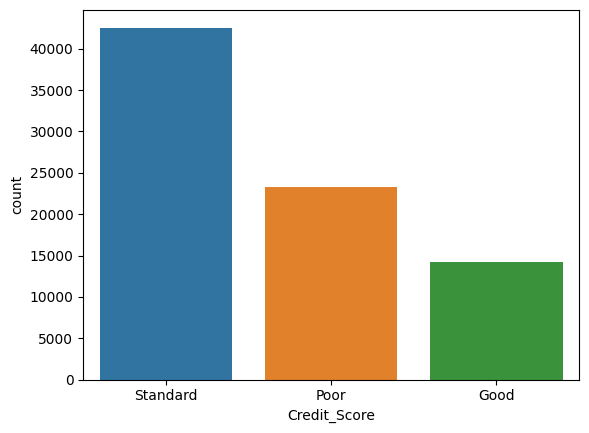

In [ ]:
sns.countplot(data=fin_train,x='Credit_Score',palette='tab10')

<Axes: xlabel='count', ylabel='Occupation'>

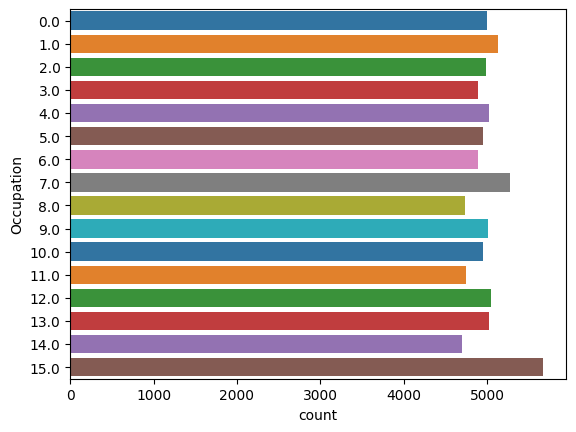

In [ ]:
sns.countplot(data=fin_train,y='Occupation',palette='tab10')

<Axes: xlabel='Credit_Mix', ylabel='count'>

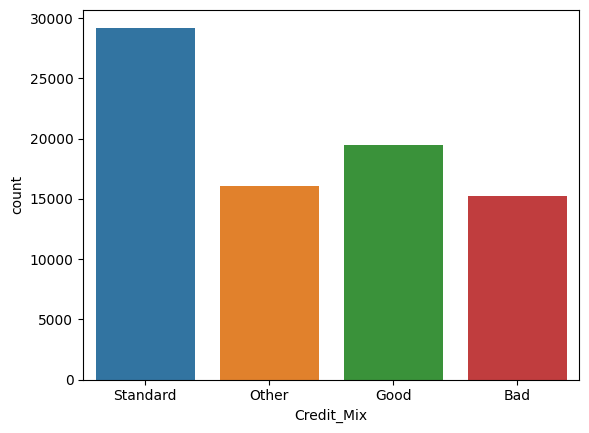

In [ ]:
sns.countplot(data=fin_train,x='Credit_Mix',palette='tab10')

<Axes: xlabel='count', ylabel='Payment_Behaviour'>

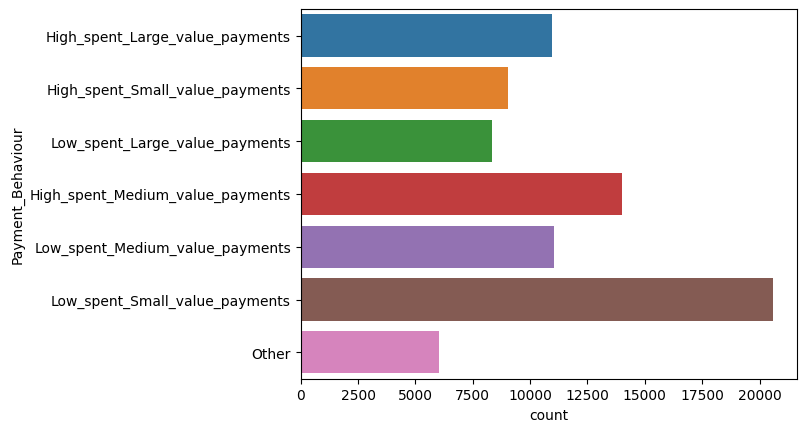

In [ ]:
sns.countplot(data=fin_train,y='Payment_Behaviour',palette='tab10')

<Axes: xlabel='Payment_of_Min_Amount', ylabel='count'>

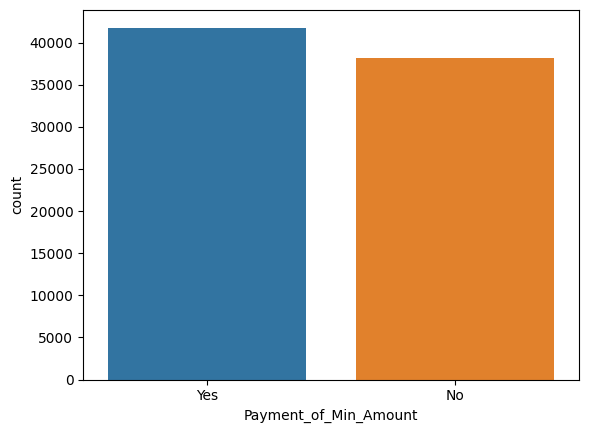

In [ ]:
sns.countplot(data=fin_train,x='Payment_of_Min_Amount',palette='tab10')

<Axes: xlabel='Credit_Score', ylabel='count'>

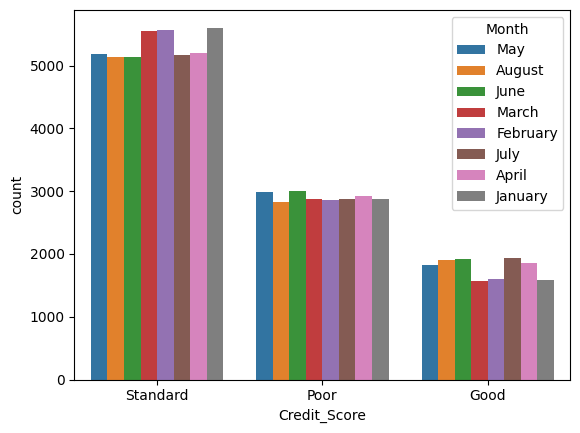

In [ ]:
sns.countplot(data=fin_train,x='Credit_Score',palette='tab10',hue='Month')

<Axes: xlabel='Age', ylabel='Count'>

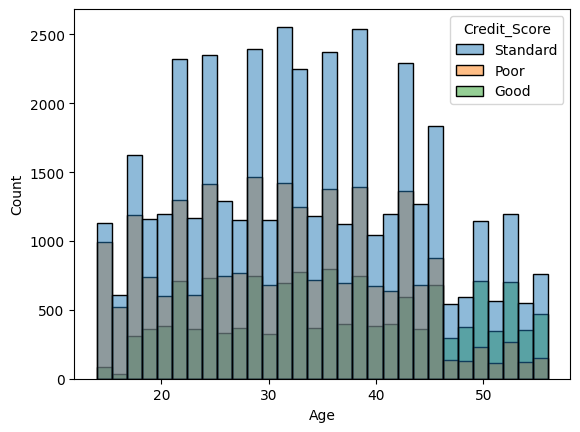

In [ ]:
sns.histplot(data=fin_train, x='Age', hue='Credit_Score', bins=30)

<Axes: xlabel='Monthly_Inhand_Salary', ylabel='Count'>

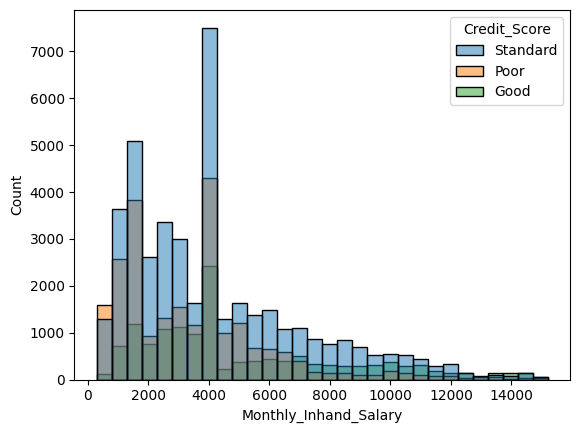

In [ ]:
sns.histplot(data=fin_train, x='Monthly_Inhand_Salary', hue='Credit_Score', bins=30)

<Axes: xlabel='Num_Credit_Card', ylabel='Count'>

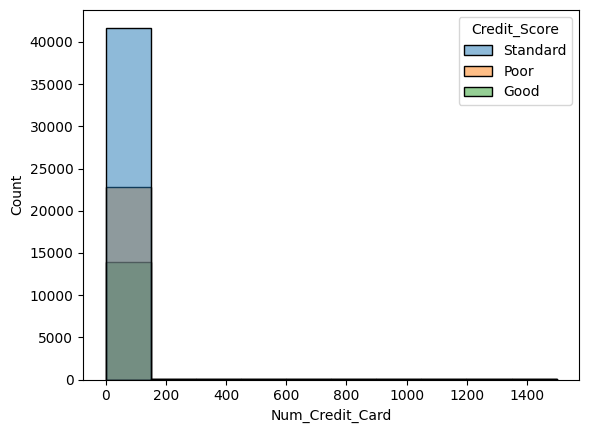

In [ ]:
sns.histplot(data=fin_train, x='Num_Credit_Card', hue='Credit_Score',bins=10)

<Axes: xlabel='Credit_Score', ylabel='Delay_from_due_date'>

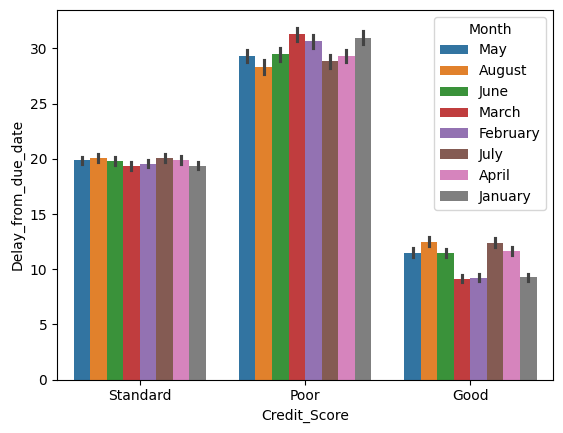

In [ ]:
sns.barplot(data=fin_train,x='Credit_Score',y='Delay_from_due_date',hue='Month')

<Axes: xlabel='Credit_Score', ylabel='Num_of_Loan'>

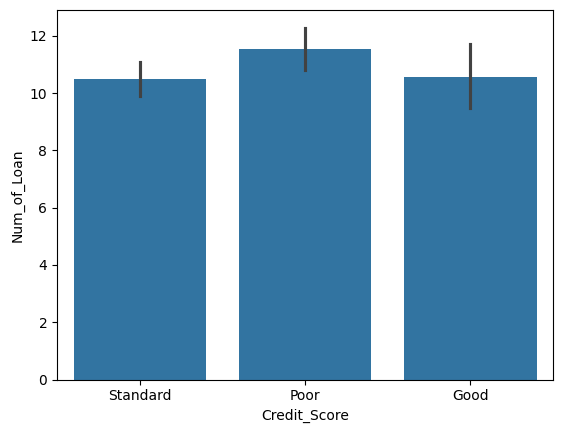

In [ ]:
sns.barplot(data=fin_train,x='Credit_Score',y='Num_of_Loan')

<Axes: xlabel='Credit_Score', ylabel='Num_Bank_Accounts'>

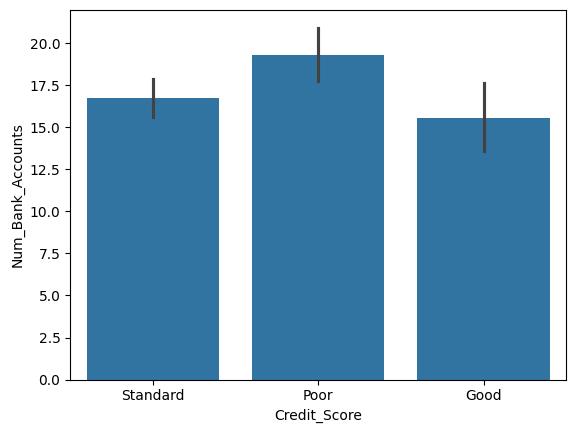

In [ ]:
sns.barplot(data=fin_train,x='Credit_Score',y='Num_Bank_Accounts')

<Axes: xlabel='Age', ylabel='Monthly_Inhand_Salary'>

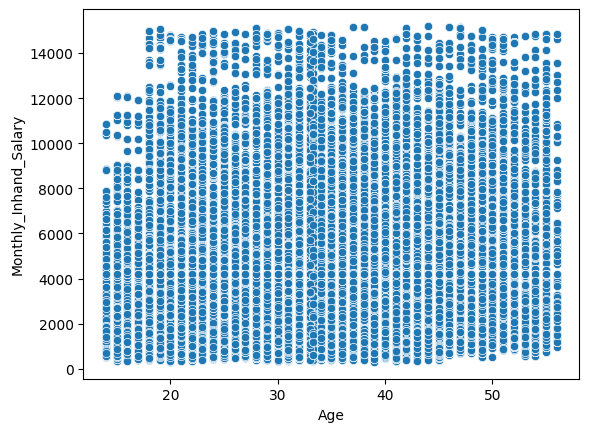

In [ ]:
sns.scatterplot(data=fin_train,x='Age',y='Monthly_Inhand_Salary')

<Axes: xlabel='Num_Bank_Accounts', ylabel='Num_Credit_Card'>

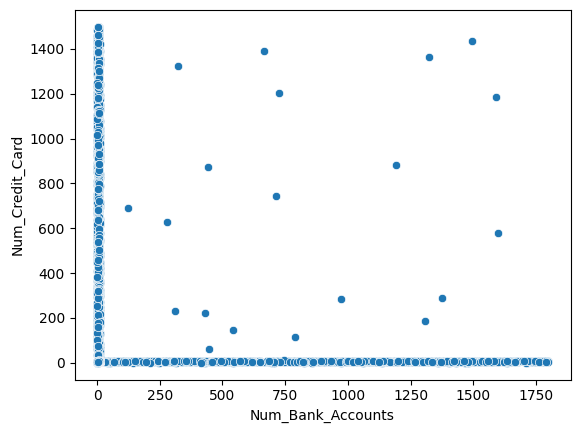

In [ ]:
sns.scatterplot(data=fin_train,x='Num_Bank_Accounts',y='Num_Credit_Card')

<Axes: xlabel='Num_of_Loan', ylabel='Delay_from_due_date'>

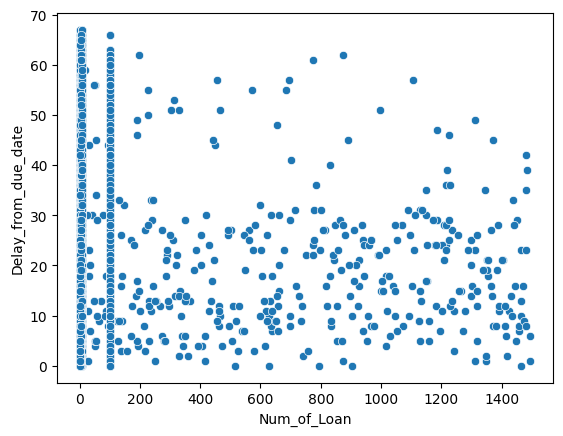

In [ ]:
sns.scatterplot(data=fin_train,x='Num_of_Loan',y='Delay_from_due_date')

<Axes: xlabel='Amount_invested_monthly', ylabel='Count'>

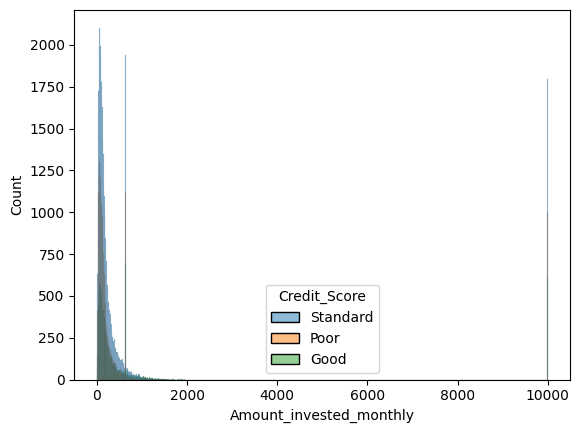

In [ ]:
sns.histplot(data=fin_train,x='Amount_invested_monthly',hue='Credit_Score')

<Axes: xlabel='Credit_History_Age', ylabel='Count'>

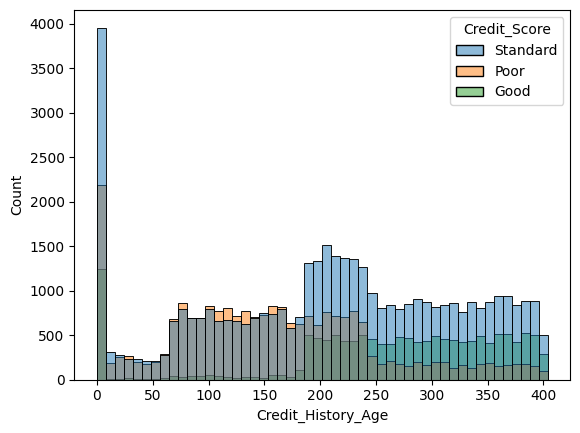

In [ ]:
sns.histplot(data=fin_train,x='Credit_History_Age',hue='Credit_Score')

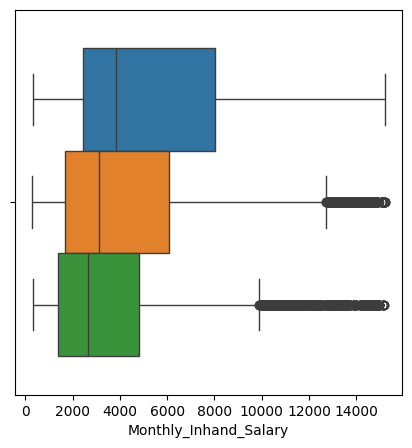

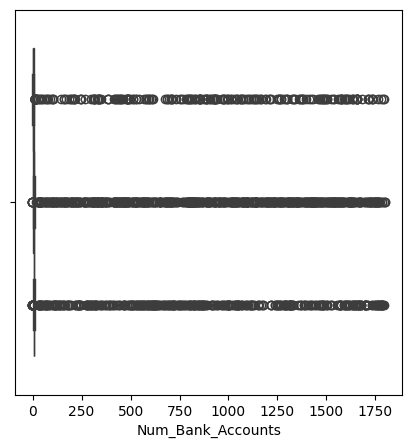

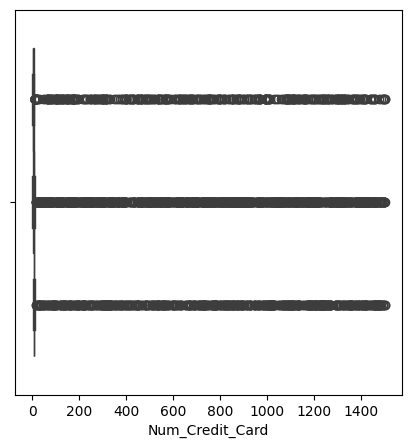

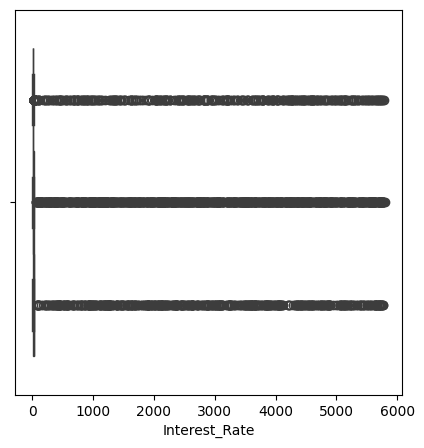

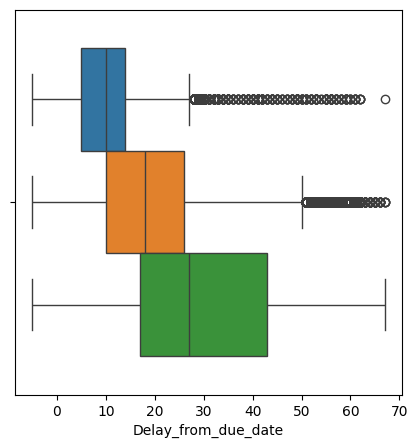

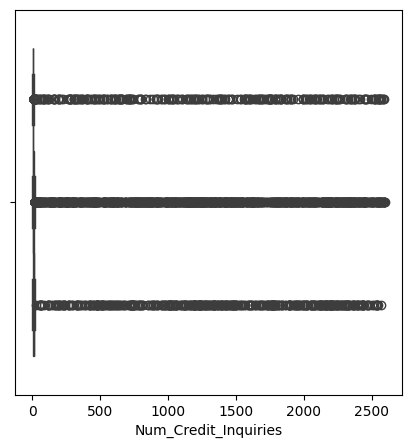

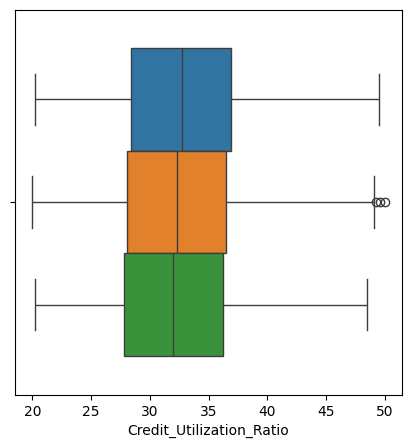

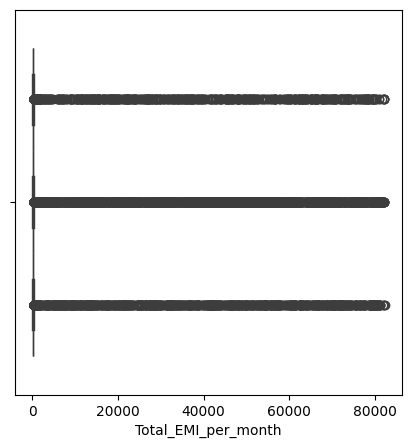

In [ ]:
for col in train.select_dtypes('number').columns:
    plt.figure(figsize=(5, 5))
    ax=sns.boxplot(data=train,x=col,hue='Credit_Score')
    ax.legend_.remove()
    plt.show()

In [ ]:
train['Credit_Score'].value_counts()

,count
Credit_Score,
Standard,53174
Poor,28998
Good,17828


In [ ]:
fin_train['Credit_Score'].replace({'Standard':1,'Poor':0,'Good':2},inplace=True)

In [ ]:
fin_val['Credit_Score'].replace({'Standard':1,'Poor':0,'Good':2},inplace=True)

<Axes: >

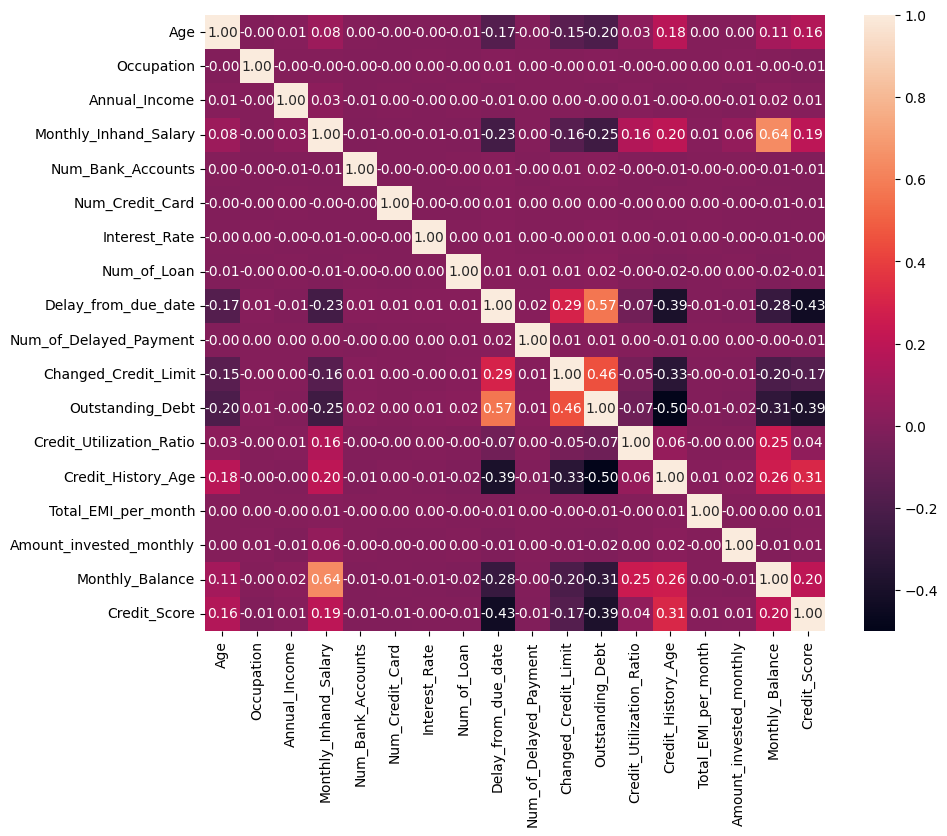

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(fin_train.select_dtypes('number').corr(),annot=True,fmt=".2f")

# convert categorical values to numerical

In [ ]:
categorical_columns = ['Credit_Mix','Payment_Behaviour','Payment_of_Min_Amount']

In [ ]:
for col in categorical_columns:
    fin_train[col] = fin_train[col].astype(str)

In [ ]:
fin_train['Occupation'].value_counts()

,count
Occupation,
15.0,5663
7.0,5268
1.0,5124
12.0,5047
4.0,5027
13.0,5021
9.0,5014
0.0,4999
2.0,4981


In [ ]:
fin_train['Month'].unique()

array(['May', 'August', 'June', 'March', 'February', 'July', 'April',
       'January'], dtype=object)

In [ ]:
fin_train['Month'].replace({'February':2, 'July':7, 'June':6, 'May':5, 'August':8, 'April':4, 'January':1,
       'March':3},inplace=True)

In [ ]:
# Initialize OneHotEncoder
one_encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = one_encoder.fit_transform(fin_train[categorical_columns])
one_hot_df = pd.DataFrame(one_hot_encoded,
                          columns=one_encoder.get_feature_names_out(categorical_columns))




In [ ]:
one_hot_df

,Credit_Mix_Bad,Credit_Mix_Good,Credit_Mix_Other,Credit_Mix_Standard,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments,Payment_Behaviour_Other,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes
0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
79996,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
79997,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
79998,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [ ]:
fin_train.shape

(80000, 28)

In [ ]:
fin_train=fin_train.drop(categorical_columns, axis=1)

# Outliers

In [ ]:
def outlier_percentage_iqr(df):
    outlier_percentages = {}
    for column in fin_train.select_dtypes(include=['number']):
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = ((fin_train[column] < lower_bound) | (fin_train[column] > upper_bound)).sum()
        outlier_percentages[column] = (outliers / len(train)) * 100
    return outlier_percentages

outlier_percentages = outlier_percentage_iqr(fin_train)
outlier_percentages


{'Month': 0.0,
 'Age': 0.0,
 'Occupation': 0.0,
 'Annual_Income': 2.226,
 'Monthly_Inhand_Salary': 3.527,
 'Num_Bank_Accounts': 1.055,
 'Num_Credit_Card': 1.825,
 'Interest_Rate': 1.614,
 'Num_of_Loan': 3.4979999999999998,
 'Delay_from_due_date': 3.2169999999999996,
 'Num_of_Delayed_Payment': 0.586,
 'Changed_Credit_Limit': 0.901,
 'Outstanding_Debt': 4.191000000000001,
 'Credit_Utilization_Ratio': 0.004,
 'Credit_History_Age': 0.0,
 'Total_EMI_per_month': 5.401,
 'Amount_invested_monthly': 6.554,
 'Monthly_Balance': 6.29,
 'Credit_Score': 0.0}

# feature Scaling

In [ ]:
dropped_column=['ID','Customer_ID','Name','SSN','Type_of_Loan']

In [ ]:
train_new=fin_train.drop(dropped_column, axis=1)

In [ ]:
train_new.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_Score
59428,5,41.0,11.0,70154.850,5696.237500,8,5,18,814,27,8,19.23,0.0,487.42,39.224627,252,92.888270,87.632538,629.102942,1
51959,8,54.0,0.0,29508.410,4190.984620,7,4,9,1,18,30,10.75,4.0,333.86,27.221135,237,16.547212,32.351596,448.704608,1
63188,5,19.0,14.0,31346.220,4190.984620,8,5,31,9,44,17,3.76,12.0,1795.98,33.204489,107,187.425136,82.924234,238.969130,1
99613,6,32.0,6.0,64901.370,5298.447500,3,5,20,0,15,30,2.94,3.0,442.06,33.682697,375,8323.000000,97.859913,691.984837,1
57804,5,32.0,12.0,7200.035,540.002917,8,8,18,3,60,17,8.51,11.0,2442.56,31.286252,170,13.723019,632.200029,294.975524,0


In [ ]:
train_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 59428 to 92975
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     80000 non-null  int64  
 1   Age                       80000 non-null  float64
 2   Occupation                80000 non-null  float64
 3   Annual_Income             80000 non-null  float64
 4   Monthly_Inhand_Salary     80000 non-null  float64
 5   Num_Bank_Accounts         80000 non-null  int64  
 6   Num_Credit_Card           80000 non-null  int64  
 7   Interest_Rate             80000 non-null  int64  
 8   Num_of_Loan               80000 non-null  int64  
 9   Delay_from_due_date       80000 non-null  int64  
 10  Num_of_Delayed_Payment    80000 non-null  int64  
 11  Changed_Credit_Limit      80000 non-null  float64
 12  Num_Credit_Inquiries      80000 non-null  object 
 13  Outstanding_Debt          80000 non-null  float64
 14  Credit_

In [ ]:
train_target=train_new['Credit_Score']

In [ ]:
new_train=train_new[['Monthly_Inhand_Salary','Num_Bank_Accounts','Num_Credit_Card','Interest_Rate','Num_of_Loan','Delay_from_due_date',
'Num_of_Delayed_Payment','Changed_Credit_Limit','Total_EMI_per_month','Amount_invested_monthly','Monthly_Balance','Outstanding_Debt']]


In [ ]:
scaler=QuantileTransformer()
scaled_new_train=scaler.fit_transform(new_train)

In [ ]:
data_2=pd.DataFrame(scaled_new_train,columns=new_train.columns)
data_2.head()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Outstanding_Debt
0,0.768122,0.812813,0.401401,0.660661,0.998196,0.724224,0.182683,0.893644,0.601279,0.294801,0.866081,0.219528
1,0.587087,0.687187,0.240741,0.322823,0.166667,0.500000,0.956456,0.589923,0.156343,0.046624,0.723247,0.147790
2,0.587087,0.812813,0.401401,0.926426,0.938438,0.893393,0.624625,0.169670,0.794840,0.276388,0.141086,0.728902
3,0.741830,0.190691,0.401401,0.734735,0.000000,0.415916,0.956456,0.127427,0.970014,0.337681,0.894515,0.197580
4,0.009280,0.812813,0.859359,0.660661,0.445445,0.982482,0.624625,0.423967,0.141436,0.894394,0.346159,0.823680


In [ ]:
df1_reset = data_2.reset_index(drop=True)
df2_reset = one_hot_df.reset_index(drop=True)

# Concatenate or merge them as needed, for example:
new_data = pd.concat([df1_reset, df2_reset], axis=1)

new_data

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Total_EMI_per_month,Amount_invested_monthly,...,Credit_Mix_Standard,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments,Payment_Behaviour_Other,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes
0,0.768122,0.812813,0.401401,0.660661,0.998196,0.724224,0.182683,0.893644,0.601279,0.294801,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.587087,0.687187,0.240741,0.322823,0.166667,0.500000,0.956456,0.589923,0.156343,0.046624,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.587087,0.812813,0.401401,0.926426,0.938438,0.893393,0.624625,0.169670,0.794840,0.276388,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.741830,0.190691,0.401401,0.734735,0.000000,0.415916,0.956456,0.127427,0.970014,0.337681,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.009280,0.812813,0.859359,0.660661,0.445445,0.982482,0.624625,0.423967,0.141436,0.894394,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,0.460750,0.190691,0.106106,0.991416,0.000000,0.090090,0.335836,0.243243,0.984568,0.695359,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
79996,0.235233,0.000000,0.749249,0.322823,0.594094,0.526527,0.233233,0.026026,0.424264,0.260014,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
79997,0.478907,0.812813,0.859359,0.959459,0.704204,0.724224,0.570571,0.942351,0.931975,0.562448,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
79998,0.220037,0.068569,0.106106,0.414915,0.166667,0.048048,0.066066,0.430430,0.129664,0.493934,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [ ]:
fin_data=pd.DataFrame(train_new[['Age','Month','Occupation','Credit_History_Age']])
fin_data

,Age,Month,Occupation,Credit_History_Age
59428,41.0,5,11.0,252
51959,54.0,8,0.0,237
63188,19.0,5,14.0,107
99613,32.0,6,6.0,375
57804,32.0,5,12.0,170
...,...,...,...,...
89460,44.0,5,10.0,271
60620,29.0,5,12.0,326
34086,24.0,7,3.0,85
58067,44.0,4,7.0,384


In [ ]:
fin_data.reset_index(drop=True,inplace=True)
new_data.reset_index(drop=True,inplace=True)
final_data=pd.concat([fin_data,new_data],axis=1)
final_data.head()

,Age,Month,Occupation,Credit_History_Age,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Credit_Mix_Standard,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments,Payment_Behaviour_Other,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes
0,41.0,5,11.0,252,0.768122,0.812813,0.401401,0.660661,0.998196,0.724224,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,54.0,8,0.0,237,0.587087,0.687187,0.240741,0.322823,0.166667,0.500000,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,19.0,5,14.0,107,0.587087,0.812813,0.401401,0.926426,0.938438,0.893393,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,32.0,6,6.0,375,0.741830,0.190691,0.401401,0.734735,0.000000,0.415916,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,32.0,5,12.0,170,0.009280,0.812813,0.859359,0.660661,0.445445,0.982482,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 29 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Age                                                 80000 non-null  float64
 1   Month                                               80000 non-null  int64  
 2   Occupation                                          80000 non-null  float64
 3   Credit_History_Age                                  80000 non-null  int64  
 4   Monthly_Inhand_Salary                               80000 non-null  float64
 5   Num_Bank_Accounts                                   80000 non-null  float64
 6   Num_Credit_Card                                     80000 non-null  float64
 7   Interest_Rate                                       80000 non-null  float64
 8   Num_of_Loan                                         80000 non-null  float64


# Feature selection

In [ ]:
# from correlation matrix
features=final_data


In [ ]:
#[['Age', 'Month', 'Occupation', 'Credit_History_Age',
                    #'Monthly_Inhand_Salary','Delay_from_due_date','Monthly_Balance',
                    # 'Outstanding_Debt','Changed_Credit_Limit','Num_of_Loan', 'Credit_Mix_Good', 'Credit_Mix_Standard',
       #'Payment_of_Min_Amount_Yes', 'Payment_of_Min_Amount_No',
       #'Credit_Mix_Bad']]

# Prepare Test Set

Apply the data transformations you used on the training set to the test set.

**Important Note:** DO NOT use `fit` on the test set.

In [ ]:
fin_val['Month'].replace({'February':2, 'July':7, 'June':6, 'May':5, 'August':8, 'April':4, 'January':1,
       'March':3},inplace=True)

In [ ]:
fin_val.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [ ]:
fin_val.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,2025
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


In [ ]:
one_hot_encoded_val = one_encoder.transform(fin_val[categorical_columns])
one_hot_df_val = pd.DataFrame(one_hot_encoded_val,
                          columns=one_encoder.get_feature_names_out(categorical_columns))




In [ ]:
new_val=fin_val[['Monthly_Inhand_Salary','Num_Bank_Accounts','Num_Credit_Card','Interest_Rate','Num_of_Loan','Delay_from_due_date',
'Num_of_Delayed_Payment','Changed_Credit_Limit','Total_EMI_per_month','Amount_invested_monthly','Monthly_Balance','Outstanding_Debt']]


In [ ]:
new_vall=['Monthly_Inhand_Salary','Num_Bank_Accounts','Num_Credit_Card','Interest_Rate','Num_of_Loan','Delay_from_due_date',
'Num_of_Delayed_Payment','Changed_Credit_Limit','Total_EMI_per_month','Amount_invested_monthly','Monthly_Balance','Outstanding_Debt']


In [ ]:
vall=fin_val.drop(new_vall,axis=1)

In [ ]:
vall=vall[['Age','Month','Occupation','Credit_History_Age']]
vall.isna().sum()

,0
Age,0
Month,0
Occupation,0
Credit_History_Age,0


In [ ]:
scaled_new_val=scaler.transform(new_val)

In [ ]:
data_2_val=pd.DataFrame(scaled_new_val,columns=new_val.columns)
data_2_val.head()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Outstanding_Debt
0,0.731029,0.960460,0.859359,0.926426,0.852853,0.907407,0.868368,0.418418,0.856927,0.846418,0.009476,0.812014
1,0.587087,0.310310,0.240741,0.414915,0.852853,0.578078,0.785285,0.754112,0.369887,0.321248,0.151524,0.500848
2,0.080994,0.960460,0.951952,0.877377,0.704204,0.651652,0.731231,0.560060,0.381273,0.428237,0.113693,0.958792
3,0.914130,0.112613,0.995197,0.070070,0.976977,0.316817,0.066066,0.529083,0.744167,0.574798,0.939256,0.189708
4,0.491166,0.904905,0.951952,0.734735,0.704204,0.869369,0.823824,0.938559,0.984408,0.402208,0.465384,0.985262


In [ ]:
df1_reset = data_2_val.reset_index(drop=True)
df2_reset = one_hot_df_val.reset_index(drop=True)
new_val = pd.concat([df1_reset, df2_reset], axis=1)

new_val

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Total_EMI_per_month,Amount_invested_monthly,...,Credit_Mix_Standard,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments,Payment_Behaviour_Other,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes
0,0.731029,0.960460,0.859359,0.926426,0.852853,0.907407,0.868368,0.418418,0.856927,0.846418,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.587087,0.310310,0.240741,0.414915,0.852853,0.578078,0.785285,0.754112,0.369887,0.321248,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.080994,0.960460,0.951952,0.877377,0.704204,0.651652,0.731231,0.560060,0.381273,0.428237,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,0.914130,0.112613,0.995197,0.070070,0.976977,0.316817,0.066066,0.529083,0.744167,0.574798,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.491166,0.904905,0.951952,0.734735,0.704204,0.869369,0.823824,0.938559,0.984408,0.402208,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,0.587087,0.000000,0.578078,0.000000,0.000000,0.252753,0.233233,0.339288,0.000000,0.894394,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
19996,0.825511,0.190691,0.240741,0.492492,0.779780,0.316817,0.731231,0.361361,0.912769,1.000000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
19997,0.912967,0.434434,0.401401,0.369369,0.000000,0.651652,0.233233,0.785786,0.000000,0.939859,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
19998,0.851366,0.560060,0.749249,0.844344,0.779780,0.998999,0.785285,0.129129,0.945717,0.834924,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
vall.shape

(20000, 4)

In [ ]:
new_val.shape

(20000, 25)

In [ ]:
new_val = new_val.reset_index(drop=True)
vall = vall.reset_index(drop=True)
new_val[['Age','Month','Occupation','Credit_History_Age']]=vall[['Age','Month','Occupation','Credit_History_Age']]
new_val.isna().sum()


,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0
Num_of_Loan,0
Delay_from_due_date,0
Num_of_Delayed_Payment,0
Changed_Credit_Limit,0
Total_EMI_per_month,0
Amount_invested_monthly,0


In [ ]:
new_val.shape

(20000, 29)

In [ ]:
val=new_val[features.columns]

In [ ]:
val.isna().sum()

,0
Age,0
Month,0
Occupation,0
Credit_History_Age,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0
Num_of_Loan,0
Delay_from_due_date,0


In [ ]:
val.shape
features.shape

(80000, 29)

----------------------

# `05` Decision Tree Classifier

Using `sklearn` implementation of decision tree classifiers to model the data.

Hint: Look for `sklearn.tree.DecisionTreeClassifier` class.

## `i` Baseline Model Training

Initializing the model with initial parameters, fitting it to the training data, and get a baseline model.

Use:
- `random_state` $= 1234$

In [ ]:
dt=DecisionTreeClassifier(random_state=1234,class_weight='balanced')
dt.fit(features,train_target)

DecisionTreeClassifier(class_weight='balanced', random_state=1234)

## `ii` Model Evaluation

Evaluate the baseline model performance using classification metrics, e.g. **Accuracy**, **Precision**, $F_1 \space Score$, **Confusion Matrix** etc.

Which metric is more reliable?

In [ ]:
dt.tree_.max_depth

44

In [ ]:
dt.score(features,train_target)

1.0

In [ ]:
y_pred=dt.predict(val)

In [ ]:
val_target=fin_val['Credit_Score']

In [ ]:

accuracy_score(val_target,y_pred)

0.6924

In [ ]:
precision_score(val_target,y_pred,average='weighted')

0.691273274832527

In [ ]:
f1_score(val_target,y_pred,average='weighted')

0.6916449991812755

In [ ]:
confusion_matrix(val_target,y_pred)

array([[3830, 1753,  176],
       [1685, 7856, 1068],
       [ 180, 1290, 2162]])

<Axes: >

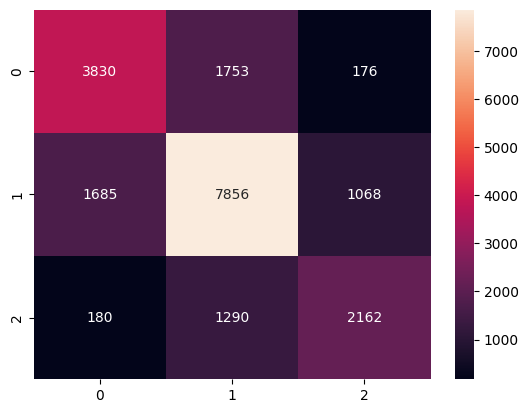

In [ ]:
sns.heatmap(confusion_matrix(val_target,y_pred),annot=True,fmt="d")

## `iii` Regularization Mode: On

Let's try contraining the model a bit. Change the default $max_depth$ parameter.

`Q` Does this simple regularization make the model generalize better?

In [ ]:
dt=DecisionTreeClassifier(random_state=1234,class_weight='balanced',max_depth=10)
dt.fit(features,train_target)


DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=1234)

In [ ]:
dt.score(features,train_target)

0.6965375

In [ ]:
y_pred=dt.predict(val)

In [ ]:
print('accuracy_score=',accuracy_score(val_target,y_pred))
print('precision_score=',precision_score(val_target,y_pred,average='weighted'))
print('f1_score=',f1_score(val_target,y_pred,average='weighted'))


accuracy_score= 0.676
precision_score= 0.7255620434944058
f1_score= 0.6789346681786317


## `iv` Tuning Hyperparameters

Try different **reasonable & logical** regularization hyperparameter values and evaluate.

`Q` What is the best hyperparamters value combination?

`Note:` Make sure to tune only reasonable hyperparameter values as per the dataset characteristics.

`Note:` Make sure you elaborate your reasoning behind selecting each of the hyperparameters.

`Hint:` You might want to use `sklearn.model_selection.RandomizedSearchCV` or `sklearn.model_selection.GridSearchCV` classes.

`Hint:` It could be useful, and time saving, to start the tuning with a wider range using `RandomizedSearchCV` then switch to a finer range using `GridSearchCV` once you have found the near optimal area for the hyperparameter.

In [ ]:
params={'max_depth':[10,15,30,35],'min_samples_leaf':[100,500,1000],
        'max_features':[10,15,20],'min_samples_split':[100,200,300,1000],
        'criterion':['gini','entropy']
        }
dt_Grid=GridSearchCV (
    DecisionTreeClassifier(),
    params,
    cv=3,
    verbose=3
    )
dt_Grid.fit(features,train_target)

Fitting 3 folds for each of 288 candidates, totalling 864 fits
[CV 1/3] END criterion=gini, max_depth=10, max_features=10, min_samples_leaf=100, min_samples_split=100;, score=0.692 total time=   0.6s
[CV 2/3] END criterion=gini, max_depth=10, max_features=10, min_samples_leaf=100, min_samples_split=100;, score=0.696 total time=   0.6s
[CV 3/3] END criterion=gini, max_depth=10, max_features=10, min_samples_leaf=100, min_samples_split=100;, score=0.699 total time=   0.5s
[CV 1/3] END criterion=gini, max_depth=10, max_features=10, min_samples_leaf=100, min_samples_split=200;, score=0.685 total time=   0.3s
[CV 2/3] END criterion=gini, max_depth=10, max_features=10, min_samples_leaf=100, min_samples_split=200;, score=0.692 total time=   0.3s
[CV 3/3] END criterion=gini, max_depth=10, max_features=10, min_samples_leaf=100, min_samples_split=200;, score=0.692 total time=   0.2s
[CV 1/3] END criterion=gini, max_depth=10, max_features=10, min_samples_leaf=100, min_samples_split=300;, score=0.6

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [10, 15, 30, 35],
                         'max_features': [10, 15, 20],
                         'min_samples_leaf': [100, 500, 1000],
                         'min_samples_split': [100, 200, 300, 1000]},
             verbose=3)

In [ ]:
dt_Grid.best_estimator_

DecisionTreeClassifier(max_depth=15, max_features=20, min_samples_leaf=100,
                       min_samples_split=100)

In [ ]:
dt_Grid.score(features,train_target)

0.718975

## `ii` Model Evaluation

Evaluate the baseline model performance using classification metrics, e.g. **Accuracy**, **Precision**, $F_1 \space Score$, **Confusion Matrix** etc.

`Q` Which metric is more reliable?
`Q` Compare the results to those of `sklearn.svm.LinearSVC` class. Also, is there a difference in the training time?

In [ ]:
y_pred=dt_Grid.predict(val)
print('accuracy_score=',accuracy_score(val_target,y_pred))
print('precision_score=',precision_score(val_target,y_pred,average='weighted'))
print('f1_score=',f1_score(val_target,y_pred,average='weighted'))
print('all_scores=',classification_report(val_target,y_pred))


accuracy_score= 0.6975
precision_score= 0.6971125342229716
f1_score= 0.6970766354517884
all_scores=               precision    recall  f1-score   support

           0       0.70      0.66      0.68      5759
           1       0.73      0.75      0.74     10609
           2       0.60      0.60      0.60      3632

    accuracy                           0.70     20000
   macro avg       0.67      0.67      0.67     20000
weighted avg       0.70      0.70      0.70     20000



## `v` Feature Importance

Explore the feature importances calculated by the best model.

`Note:` Visualizing the importances would help extract insights.

`Q` Do the importance values make sense?

`Q` Can you intrepet the importance of the few top features?

In [ ]:
dt=DecisionTreeClassifier(criterion='entropy', max_depth=15, max_features=20,
                       min_samples_leaf=500, min_samples_split=300)
dt.fit(features,train_target)

DecisionTreeClassifier(criterion='entropy', max_depth=15, max_features=20,
                       min_samples_leaf=500, min_samples_split=300)

In [ ]:
dt.feature_importances_

array([0.00074083, 0.05860281, 0.0007272 , 0.00448648, 0.00209929,
       0.00404656, 0.03173719, 0.06208761, 0.00082848, 0.0437168 ,
       0.00774065, 0.03195942, 0.01059429, 0.0023545 , 0.0012003 ,
       0.43302924, 0.        , 0.17398317, 0.04162398, 0.05709113,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.00563229, 0.        , 0.        , 0.02571779])

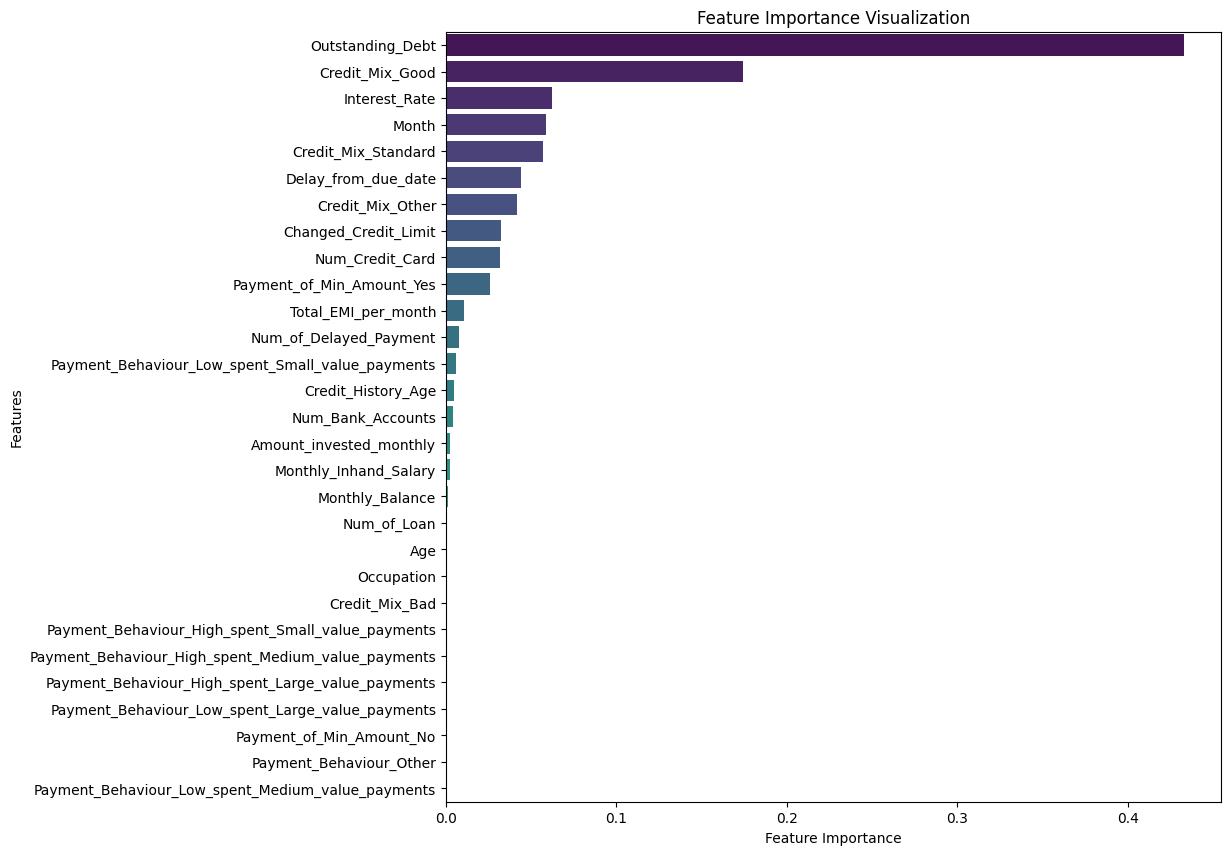

In [ ]:
feature_importances = dt.feature_importances_
feature_names = dt.feature_names_in_

sorted_idx = np.argsort(feature_importances)[::-1]
sorted_importances = feature_importances[sorted_idx]
sorted_names = np.array(feature_names)[sorted_idx]

# Plot
plt.figure(figsize=(10, 10))
sns.barplot(x=sorted_importances, y=sorted_names, palette="viridis")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance Visualization")
plt.show()


-----------------------------

# `Bonus` Better Flow

For the model to be production-ready, we need to integrate it into a pipeline along with the data preparation flow.

Hint: Look up `sklearn.pipeline.Pipeline` class.

In [ ]:
DT = Pipeline([
    ('model', DecisionTreeClassifier(
        random_state=1234,
        class_weight="balanced",
        max_features=15,
        ccp_alpha=0.005
    ))
])

In [ ]:
cv_scores = cross_val_score(DT, features, train_target, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean accuracy:", cv_scores.mean())

Cross-validation scores: [0.648     0.6495    0.645375  0.6519375 0.6426875]
Mean accuracy: 0.6475


In [ ]:
DT.fit(features,train_target)

Pipeline(steps=[('model',
                 DecisionTreeClassifier(ccp_alpha=0.005,
                                        class_weight='balanced',
                                        max_features=15, random_state=1234))])

In [ ]:
DT.score(features,train_target)

0.6505875

In [ ]:
y_pred=DT.predict(val)

In [ ]:
print('accuracy_score=',accuracy_score(val_target,y_pred))
print('precision_score=',precision_score(val_target,y_pred,average='weighted'))
print('f1_score=',f1_score(val_target,y_pred,average='weighted'))


accuracy_score= 0.65085
precision_score= 0.712511769848271
f1_score= 0.6540735984527569


In [ ]:
class_names=['Standard','Poor','Good']

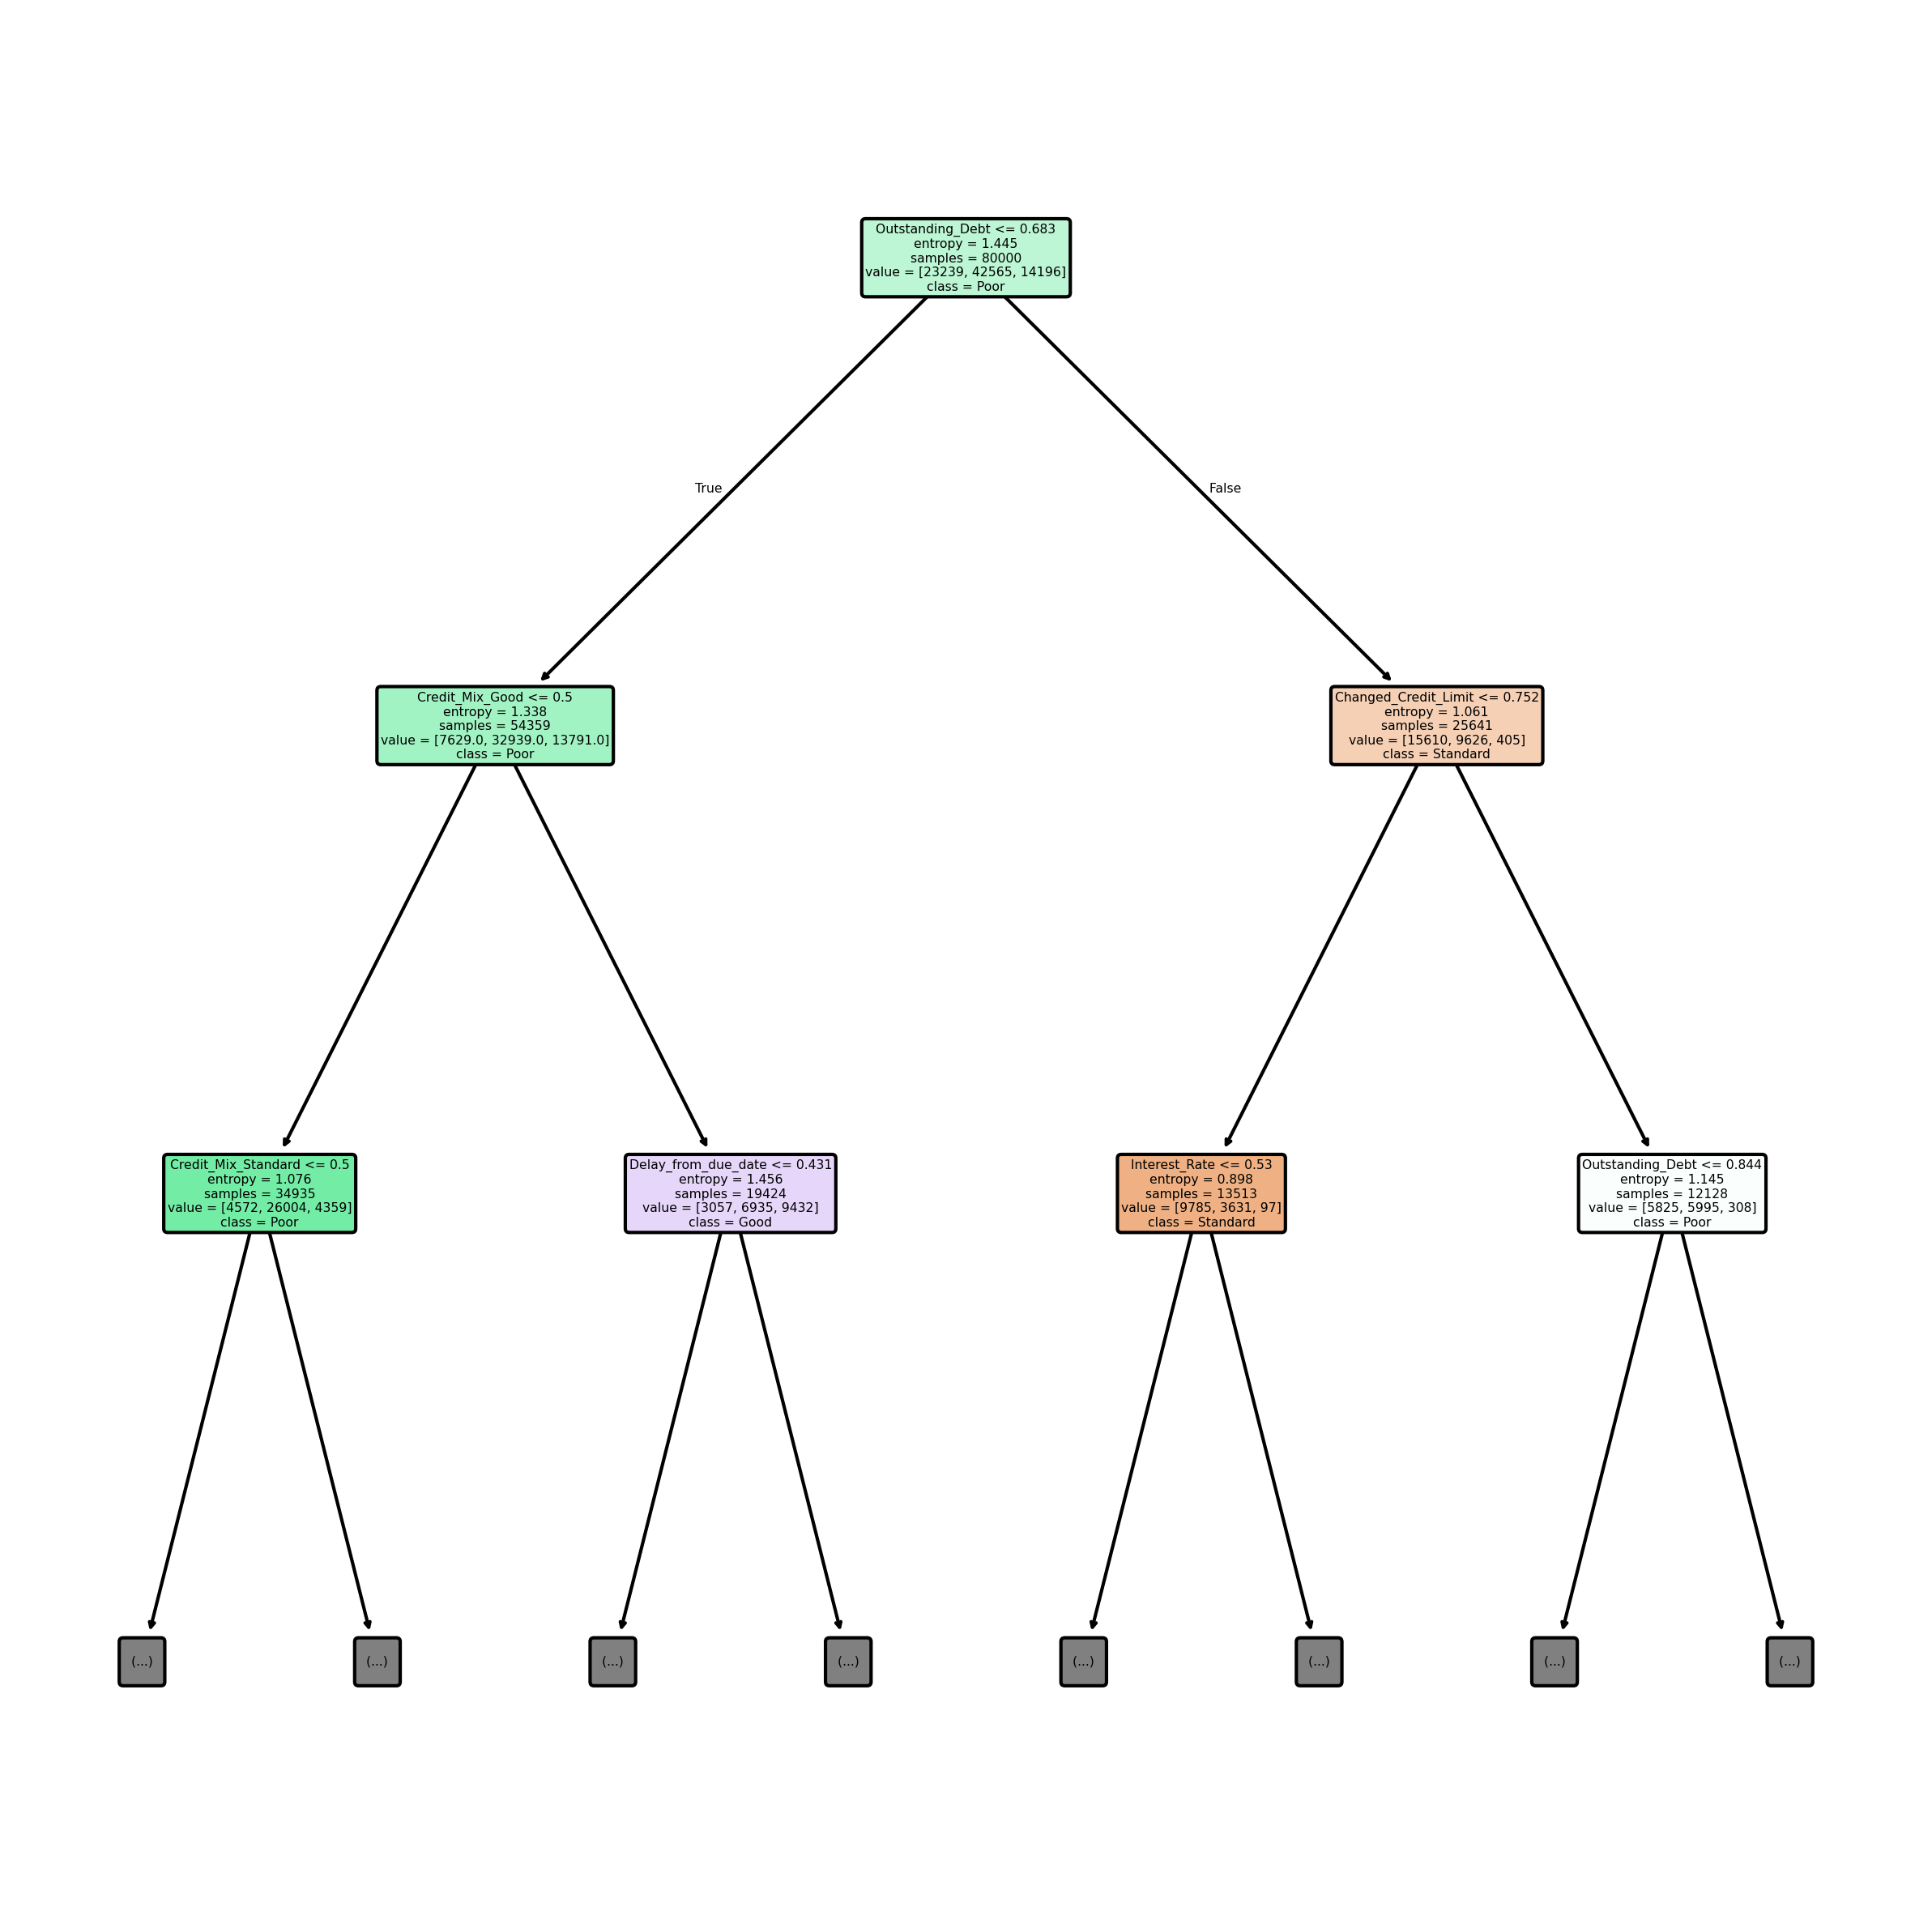

In [ ]:
plt.figure(dpi=300, figsize=(10, 10))
plot_tree(dt,max_depth=2 ,rounded=True, filled=True, class_names=class_names, feature_names=dt.feature_names_in_);

----------------------------------------------

$$ Wish \space you \space all \space the \space best \space ♡ $$
$$ Abdelrahman \space Eid $$